In [3]:
# ============================================================
# TASK 5: MACHINE LEARNING MODEL TRAINING
# AI-Powered Symptom Checker Assistant
# ============================================================

# Data Handling
import pandas as pd
import numpy as np

# Data Splitting
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("data/processed/dataset_Africa20.csv")

print("Dataset Loaded Successfully")
print("-" * 50)

print("Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Loaded Successfully
--------------------------------------------------
Shape: (146, 18)

First 5 Rows:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Allergy,continuous_sneezing,shivering,chills,watering_from_eyes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Allergy,shivering,chills,watering_from_eyes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Allergy,continuous_sneezing,chills,watering_from_eyes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Allergy,continuous_sneezing,shivering,watering_from_eyes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Allergy,continuous_sneezing,shivering,chills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Dataset Information")
print("-" * 50)

df.info()

print("\nMissing Values")
print("-" * 50)
print(df.isnull().sum())

print("\nDisease Distribution")
print("-" * 50)
print(df["Disease"].value_counts())

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Disease     146 non-null    str  
 1   Symptom_1   146 non-null    str  
 2   Symptom_2   146 non-null    str  
 3   Symptom_3   146 non-null    str  
 4   Symptom_4   122 non-null    str  
 5   Symptom_5   101 non-null    str  
 6   Symptom_6   92 non-null     str  
 7   Symptom_7   91 non-null     str  
 8   Symptom_8   76 non-null     str  
 9   Symptom_9   65 non-null     str  
 10  Symptom_10  56 non-null     str  
 11  Symptom_11  30 non-null     str  
 12  Symptom_12  19 non-null     str  
 13  Symptom_13  18 non-null     str  
 14  Symptom_14  18 non-null     str  
 15  Symptom_15  18 non-null     str  
 16  Symptom_16  10 non-null     str  
 17  Symptom_17  1 non-null      str  
dtypes: str(18)
memory usage: 20.7 KB

Missing Values
-

In [7]:
# ============================================================
# SECTION 4: HANDLE MISSING SYMPTOM VALUES
# ============================================================

# Replace missing symptom values with "none"
df.fillna("none", inplace=True)

print("=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)

print(df.isnull().sum())

MISSING VALUES AFTER CLEANING
Disease       0
Symptom_1     0
Symptom_2     0
Symptom_3     0
Symptom_4     0
Symptom_5     0
Symptom_6     0
Symptom_7     0
Symptom_8     0
Symptom_9     0
Symptom_10    0
Symptom_11    0
Symptom_12    0
Symptom_13    0
Symptom_14    0
Symptom_15    0
Symptom_16    0
Symptom_17    0
dtype: int64


In [9]:
# ============================================================
# SECTION 5: CREATE FEATURES AND TARGET
# ============================================================

# Features (Symptoms)
X = df.drop(columns=["Disease"])

# Target (Disease)
y = df["Disease"]

print("=" * 60)
print("FEATURES AND TARGET CREATED")
print("=" * 60)

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

print("\nFirst 5 Feature Rows:")
display(X.head())

print("\nFirst 5 Target Values:")
display(y.head())

FEATURES AND TARGET CREATED
Feature Shape: (146, 17)
Target Shape : (146,)

First 5 Feature Rows:


,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,continuous_sneezing,shivering,chills,watering_from_eyes,none,none,none,none,none,none,none,none,none,none,none,none,none
1,shivering,chills,watering_from_eyes,none,none,none,none,none,none,none,none,none,none,none,none,none,none
2,continuous_sneezing,chills,watering_from_eyes,none,none,none,none,none,none,none,none,none,none,none,none,none,none
3,continuous_sneezing,shivering,watering_from_eyes,none,none,none,none,none,none,none,none,none,none,none,none,none,none
4,continuous_sneezing,shivering,chills,none,none,none,none,none,none,none,none,none,none,none,none,none,none



First 5 Target Values:


0    Allergy
1    Allergy
2    Allergy
3    Allergy
4    Allergy
Name: Disease, dtype: str

In [10]:
# ============================================================
# SECTION 6: ENCODE SYMPTOM FEATURES
# ============================================================

X_encoded = pd.get_dummies(X)

print("=" * 60)
print("FEATURE ENCODING COMPLETED")
print("=" * 60)

print("Original Feature Shape :", X.shape)
print("Encoded Feature Shape  :", X_encoded.shape)

print("\nFirst 5 Encoded Rows:")
display(X_encoded.head())

FEATURE ENCODING COMPLETED
Original Feature Shape : (146, 17)
Encoded Feature Shape  : (146, 231)

First 5 Encoded Rows:


,Symptom_1_acidity,Symptom_1_bladder_discomfort,Symptom_1_breathlessness,Symptom_1_burning_micturition,Symptom_1_chest_pain,Symptom_1_chills,Symptom_1_continuous_sneezing,Symptom_1_cough,Symptom_1_fatigue,Symptom_1_headache,...,Symptom_15_blood_in_sputum,Symptom_15_chest_pain,Symptom_15_loss_of_smell,Symptom_15_none,Symptom_16_blood_in_sputum,Symptom_16_loss_of_smell,Symptom_16_muscle_pain,Symptom_16_none,Symptom_17_muscle_pain,Symptom_17_none
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,True
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,True
4,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,True


In [11]:
# ============================================================
# SECTION 7: ENCODE TARGET LABELS
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("=" * 60)
print("TARGET LABEL ENCODING COMPLETED")
print("=" * 60)

print("Number of Disease Classes:", len(label_encoder.classes_))

print("\nDisease Classes:")
print(label_encoder.classes_)

TARGET LABEL ENCODING COMPLETED
Number of Disease Classes: 20

Disease Classes:
['AIDS' 'Allergy' 'Arthritis' 'Bronchial Asthma' 'Chicken pox'
 'Common Cold' 'Diabetes' 'Drug Reaction' 'Gastroenteritis' 'Heart attack'
 'Hypertension' 'Hypoglycemia' 'Jaundice' 'Malaria' 'Migraine'
 'Paralysis (brain hemorrhage)' 'Pneumonia' 'Tuberculosis' 'Typhoid'
 'Urinary tract infection']


In [12]:
# ============================================================
# SECTION 8: TRAIN-TEST SPLIT
# ============================================================

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("=" * 60)
print("TRAIN-TEST SPLIT COMPLETED")
print("=" * 60)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

TRAIN-TEST SPLIT COMPLETED
Training Features : (116, 231)
Testing Features  : (30, 231)

Training Labels : (116,)
Testing Labels  : (30,)


In [13]:
# ============================================================
# SECTION 10: DECISION TREE CLASSIFIER
# ============================================================

from sklearn.tree import DecisionTreeClassifier

In [14]:
# ============================================================
# TRAIN DECISION TREE MODEL
# ============================================================

# Create the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("=" * 60)
print("DECISION TREE MODEL TRAINED SUCCESSFULLY")
print("=" * 60)

DECISION TREE MODEL TRAINED SUCCESSFULLY


In [15]:
# ============================================================
# MAKE PREDICTIONS
# ============================================================

y_pred_dt = dt_model.predict(X_test)

print("=" * 60)
print("PREDICTIONS COMPLETED")
print("=" * 60)

print("First 10 Predictions")

print(y_pred_dt[:10])

PREDICTIONS COMPLETED
First 10 Predictions
[12 10  5 13  4 15 13 16 13  6]


In [16]:
# ============================================================
# DECISION TREE EVALUATION
# ============================================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")

DECISION TREE PERFORMANCE
Accuracy : 0.7667
Precision: 0.8222
Recall   : 0.7667
F1-Score : 0.7478


In [17]:
# ============================================================
# DECISION TREE CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

DECISION TREE CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                        AIDS       0.00      0.00      0.00         1
                     Allergy       1.00      1.00      1.00         1
                   Arthritis       1.00      1.00      1.00         1
            Bronchial Asthma       0.00      0.00      0.00         1
                 Chicken pox       1.00      0.50      0.67         2
                 Common Cold       0.50      1.00      0.67         2
                    Diabetes       0.67      1.00      0.80         2
               Drug Reaction       0.33      1.00      0.50         1
             Gastroenteritis       1.00      1.00      1.00         1
                Heart attack       1.00      1.00      1.00         1
                Hypertension       1.00      1.00      1.00         1
                Hypoglycemia       1.00      0.50      0.67         2
                    Jaundice       1.00      0.50    

In [18]:
# ============================================================
# SECTION 11: RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

In [19]:
# ============================================================
# TRAIN RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("=" * 60)
print("RANDOM FOREST MODEL TRAINED SUCCESSFULLY")
print("=" * 60)

RANDOM FOREST MODEL TRAINED SUCCESSFULLY


In [20]:
# ============================================================
# RANDOM FOREST PREDICTIONS
# ============================================================

y_pred_rf = rf_model.predict(X_test)

print("=" * 60)
print("RANDOM FOREST PREDICTIONS COMPLETED")
print("=" * 60)

print(y_pred_rf[:10])

RANDOM FOREST PREDICTIONS COMPLETED
[12 10 11 13  4 15 13 16 14  4]


In [21]:
# ============================================================
# RANDOM FOREST PERFORMANCE
# ============================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy : 0.9667
Precision: 0.9778
Recall   : 0.9667
F1-Score : 0.9644


In [22]:
# ============================================================
# SECTION 12: K-NEAREST NEIGHBORS (KNN)
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

In [23]:
# ============================================================
# TRAIN KNN MODEL
# ============================================================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

print("=" * 60)
print("KNN MODEL TRAINED SUCCESSFULLY")
print("=" * 60)

KNN MODEL TRAINED SUCCESSFULLY


In [24]:
# ============================================================
# KNN PREDICTIONS
# ============================================================

y_pred_knn = knn_model.predict(X_test)

print("=" * 60)
print("KNN PREDICTIONS COMPLETED")
print("=" * 60)

print(y_pred_knn[:10])

KNN PREDICTIONS COMPLETED
[12 10 11 13  4  8 13 16 14  4]


In [25]:
# ============================================================
# KNN PERFORMANCE
# ============================================================

knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("KNN PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")

KNN PERFORMANCE
Accuracy : 0.9333
Precision: 0.9111
Recall   : 0.9333
F1-Score : 0.9167


In [26]:
# ============================================================
# KNN CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("KNN CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

KNN CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                        AIDS       1.00      1.00      1.00         1
                     Allergy       1.00      1.00      1.00         1
                   Arthritis       1.00      1.00      1.00         1
            Bronchial Asthma       1.00      1.00      1.00         1
                 Chicken pox       1.00      1.00      1.00         2
                 Common Cold       1.00      1.00      1.00         2
                    Diabetes       1.00      1.00      1.00         2
               Drug Reaction       1.00      1.00      1.00         1
             Gastroenteritis       0.33      1.00      0.50         1
                Heart attack       0.00      0.00      0.00         1
                Hypertension       1.00      1.00      1.00         1
                Hypoglycemia       1.00      1.00      1.00         2
                    Jaundice       1.00      1.00      1.00    

In [27]:
# ============================================================
# SECTION 13: SUPPORT VECTOR MACHINE (SVM)
# ============================================================

from sklearn.svm import SVC

In [28]:
# ============================================================
# TRAIN SVM MODEL
# ============================================================

svm_model = SVC(
    kernel="linear",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("=" * 60)
print("SVM MODEL TRAINED SUCCESSFULLY")
print("=" * 60)

SVM MODEL TRAINED SUCCESSFULLY


In [29]:
# ============================================================
# SVM PREDICTIONS
# ============================================================

y_pred_svm = svm_model.predict(X_test)

print("=" * 60)
print("SVM PREDICTIONS COMPLETED")
print("=" * 60)

print(y_pred_svm[:10])

SVM PREDICTIONS COMPLETED
[12 10 11 13  4 15 13 16 14  4]


In [30]:
# ============================================================
# SVM PERFORMANCE
# ============================================================

svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("SVM PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

SVM PERFORMANCE
Accuracy : 0.9667
Precision: 0.9778
Recall   : 0.9667
F1-Score : 0.9644


In [31]:
# ============================================================
# SVM CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("SVM CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

SVM CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                        AIDS       1.00      1.00      1.00         1
                     Allergy       1.00      1.00      1.00         1
                   Arthritis       1.00      1.00      1.00         1
            Bronchial Asthma       1.00      1.00      1.00         1
                 Chicken pox       1.00      1.00      1.00         2
                 Common Cold       0.67      1.00      0.80         2
                    Diabetes       1.00      1.00      1.00         2
               Drug Reaction       1.00      1.00      1.00         1
             Gastroenteritis       1.00      1.00      1.00         1
                Heart attack       1.00      1.00      1.00         1
                Hypertension       1.00      1.00      1.00         1
                Hypoglycemia       1.00      1.00      1.00         2
                    Jaundice       1.00      1.00      1.00    

In [32]:
# ============================================================
# SECTION 14: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

In [33]:
# ============================================================
# TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("=" * 60)
print("LOGISTIC REGRESSION MODEL TRAINED SUCCESSFULLY")
print("=" * 60)

LOGISTIC REGRESSION MODEL TRAINED SUCCESSFULLY


In [34]:
# ============================================================
# LOGISTIC REGRESSION PREDICTIONS
# ============================================================

y_pred_lr = lr_model.predict(X_test)

print("=" * 60)
print("LOGISTIC REGRESSION PREDICTIONS COMPLETED")
print("=" * 60)

print(y_pred_lr[:10])

LOGISTIC REGRESSION PREDICTIONS COMPLETED
[12 10 11 13  4 15 13 16 14  4]


In [35]:
# ============================================================
# LOGISTIC REGRESSION PERFORMANCE
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [36]:
# ============================================================
# LOGISTIC REGRESSION CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 60)
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

LOGISTIC REGRESSION CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                        AIDS       1.00      1.00      1.00         1
                     Allergy       1.00      1.00      1.00         1
                   Arthritis       1.00      1.00      1.00         1
            Bronchial Asthma       1.00      1.00      1.00         1
                 Chicken pox       1.00      1.00      1.00         2
                 Common Cold       1.00      1.00      1.00         2
                    Diabetes       1.00      1.00      1.00         2
               Drug Reaction       1.00      1.00      1.00         1
             Gastroenteritis       1.00      1.00      1.00         1
                Heart attack       1.00      1.00      1.00         1
                Hypertension       1.00      1.00      1.00         1
                Hypoglycemia       1.00      1.00      1.00         2
                    Jaundice       1.00      1.

In [ ]:

# ============================================================
# SECTION 15: MODEL COMPARISON
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Logistic Regression"
    ],
    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy,
        lr_accuracy
    ],
    "Precision":[
        dt_precision,
        rf_precision,
        knn_precision,
        svm_precision,
        lr_precision
    ],
    "Recall":[
        dt_recall,
        rf_recall,
        knn_recall,
        svm_recall,
        lr_recall
    ],
    "F1 Score":[
        dt_f1,
        rf_f1,
        knn_f1,
        svm_f1,
        lr_f1
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,SVM,0.966667,0.977778,0.966667,0.964444
2,Random Forest,0.966667,0.977778,0.966667,0.964444
3,KNN,0.933333,0.911111,0.933333,0.916667
4,Decision Tree,0.766667,0.822222,0.766667,0.747778


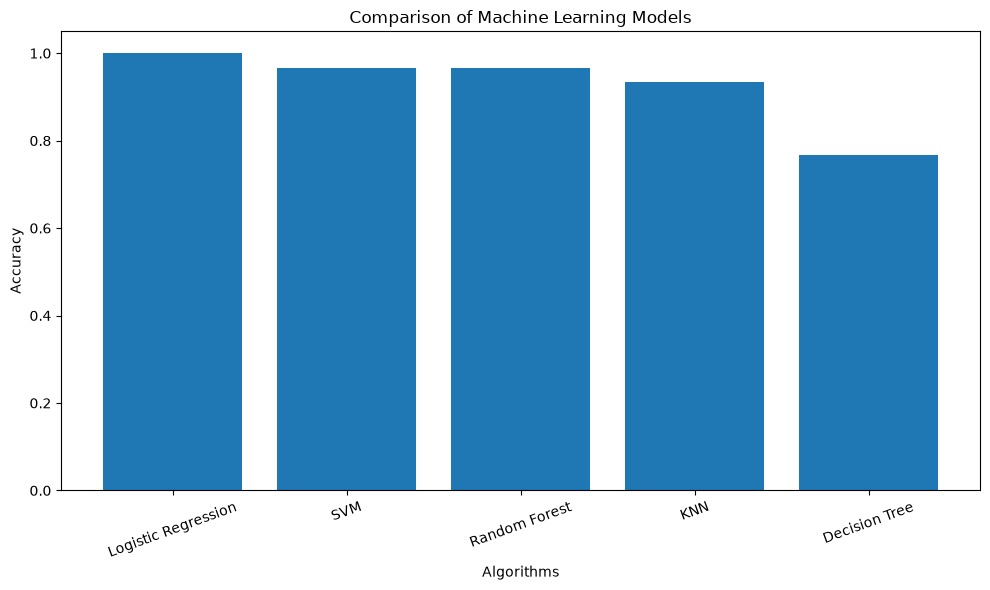

In [ ]:
# ============================================================
# SECTION 16: ACCURACY BAR CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

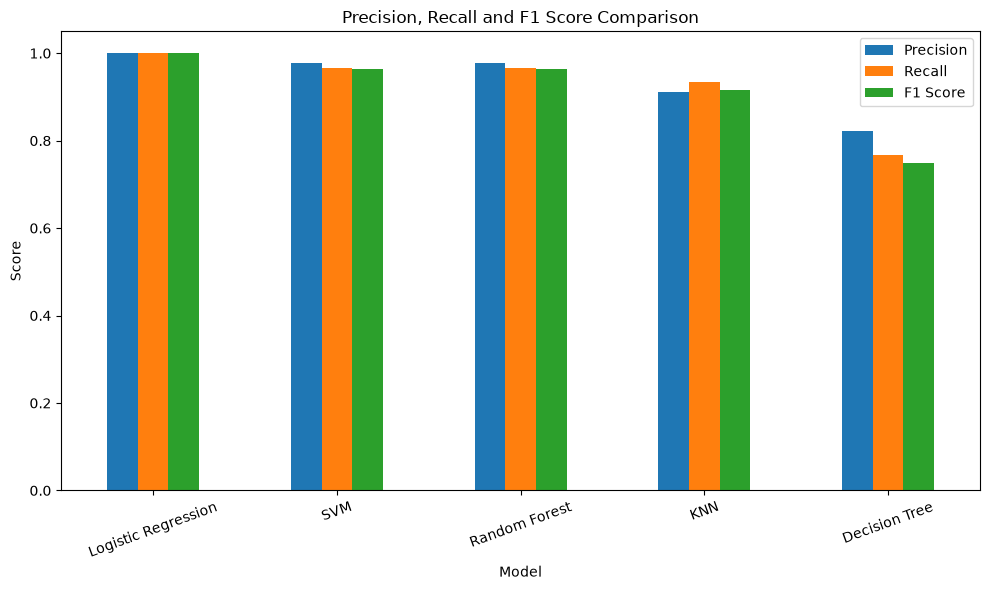

In [ ]:
# ============================================================
# SECTION 17: METRICS COMPARISON
# ============================================================

comparison.set_index("Model")[
    ["Precision","Recall","F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision, Recall and F1 Score Comparison")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

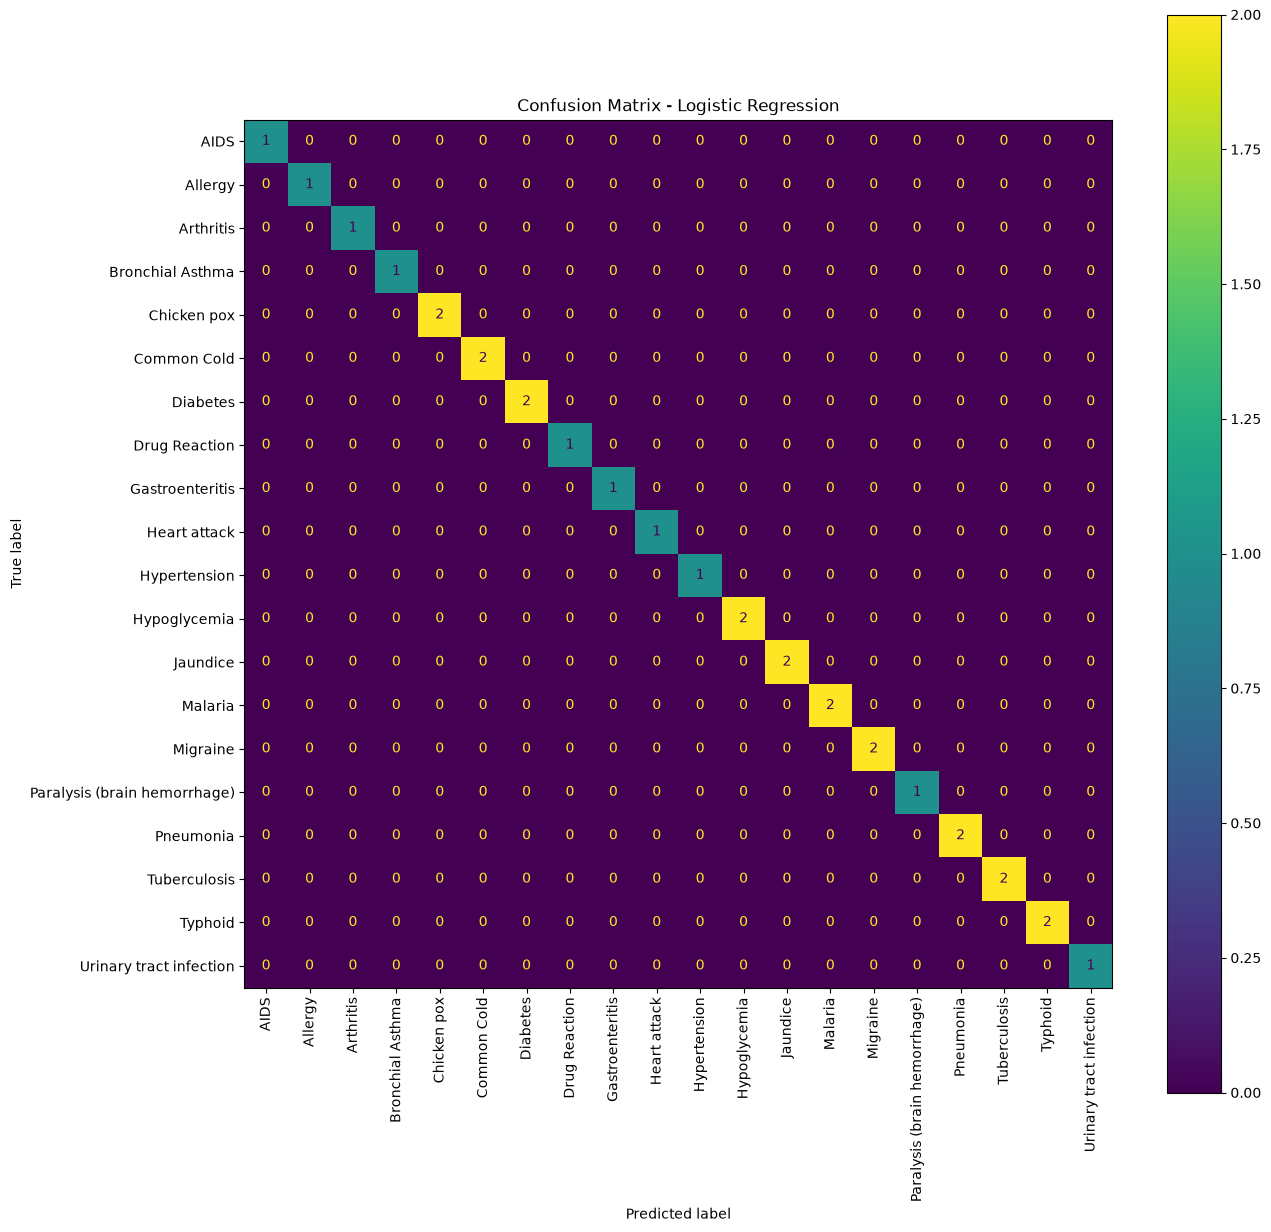

In [ ]:
# ============================================================
# SECTION 18: CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(14,14))

disp.plot(
    xticks_rotation=90,
    ax=ax
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
# ============================================================
# SECTION 19: SAVE THE MODEL
# ============================================================

import joblib

joblib.dump(
    lr_model,
    "best_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
# ============================================================
# SECTION 20: SAVE LABEL ENCODER
# ============================================================

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Label Encoder saved.")

Label Encoder saved.


In [ ]:
# ============================================================
# SECTION 21: SAVE FEATURE COLUMNS
# ============================================================

joblib.dump(
    X_encoded.columns.tolist(),
    "feature_columns.pkl"
)

print("Feature Columns saved.")

Feature Columns saved.


In [ ]:
# ============================================================
# SECTION 22: SAVE COMPARISON RESULTS
# ============================================================

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,SVM,0.966667,0.977778,0.966667,0.964444
2,Random Forest,0.966667,0.977778,0.966667,0.964444
3,KNN,0.933333,0.911111,0.933333,0.916667
4,Decision Tree,0.766667,0.822222,0.766667,0.747778
